## Load USDA files and inspect coverage.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Update this path to where your USDA files are saved
DATA_DIR = "."

branded = pd.read_csv(f"{DATA_DIR}/branded_food.csv", low_memory=False)
food_nutrient = pd.read_csv(f"{DATA_DIR}/food_nutrient.csv", low_memory=False)
nutrient = pd.read_csv(f"{DATA_DIR}/nutrient.csv", low_memory=False)

print("branded:", branded.shape)
print("food_nutrient:", food_nutrient.shape)
print("nutrient:", nutrient.shape)


branded: (1999950, 21)
food_nutrient: (26027437, 11)
nutrient: (477, 5)


## View sample rows

In [31]:

display(branded.head(5))
display(food_nutrient.head(5))
display(nutrient.head(5))

,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,...,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,00027000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),...,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,00051000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,...,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,00051000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,00051000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,00051000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,...,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [32]:
print("Number of branded food records:", branded["fdc_id"].nunique())

Number of branded food records: 1999950


In [33]:
# Check uniqueness of key columns

print("branded shape:", branded.shape)

print("\nfdc_id")
print("Unique fdc_id:", branded["fdc_id"].nunique())
print("Duplicate fdc_id:", branded.shape[0] - branded["fdc_id"].nunique())

print("\ngtin_upc")
print("Non-null gtin_upc:", branded["gtin_upc"].notna().sum())
print("Unique gtin_upc:", branded["gtin_upc"].nunique())
print("Duplicate gtin_upc:", branded["gtin_upc"].notna().sum() - branded["gtin_upc"].nunique())

branded shape: (1999950, 21)

fdc_id
Unique fdc_id: 1999950
Duplicate fdc_id: 0

gtin_upc
Non-null gtin_upc: 1999950
Unique gtin_upc: 465110
Duplicate gtin_upc: 1534840


In [34]:
branded_ids = set(branded["fdc_id"])

food_nutrient_ids = set(food_nutrient["fdc_id"])

print("Branded products:", len(branded_ids))
print("Food nutrient products:", len(food_nutrient_ids))

print(
    "Branded products with nutrient data:",
    len(branded_ids.intersection(food_nutrient_ids))
)

Branded products: 1999950
Food nutrient products: 1896250
Branded products with nutrient data: 1896250


In [35]:
branded["modified_date"] = pd.to_datetime(
    branded["modified_date"],
    errors="coerce"
)

print(branded["modified_date"].min())
print(branded["modified_date"].max())

2013-06-05 00:00:00
2026-04-01 00:00:00


In [36]:
barcode_latest = (
    branded
    .sort_values("modified_date")
    .drop_duplicates(
        subset=["gtin_upc"],
        keep="last"
    )
    .reset_index(drop=True)
)

print("Original rows:", len(branded))
print("Unique barcode rows:", len(barcode_latest))
print("Unique barcodes:", barcode_latest["gtin_upc"].nunique())

barcode_latest.to_csv(
    "usda_branded_products_unique_barcode.csv",
    index=False
)

Original rows: 1999950
Unique barcode rows: 465110
Unique barcodes: 465110


In [37]:
# Add nutrient names and units to food_nutrient
food_nutrient_named = food_nutrient.merge(
    nutrient,
    left_on="nutrient_id",
    right_on="id",
    how="left",
    suffixes=("", "_nutrient")
)

print(food_nutrient_named.shape)
display(food_nutrient_named.head())

(26027437, 16)


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired,id_nutrient,name,unit_name,nutrient_nbr,rank
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,1257,"Fatty acids, total trans",G,605.0,15400.0
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN,1293,"Fatty acids, total polyunsaturated",G,646.0,12900.0
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,1253,Cholesterol,MG,601.0,15700.0
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,1092,"Potassium, K",MG,306.0,5700.0
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,1008,Energy,KCAL,208.0,300.0


In [38]:
usda_branded_nutrients_long = barcode_latest.merge(
    food_nutrient_named,
    on="fdc_id",
    how="inner"
)

print(usda_branded_nutrients_long.shape)
display(usda_branded_nutrients_long.head())

(6119842, 36)


,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,...,min,max,median,footnote,min_year_acquired,id_nutrient,name,unit_name,nutrient_nbr,rank
0,605062,Cargill,NaN,NaN,00642205518029,"Turkey, water, contains less than 2% salt, dex...",NaN,74.0,g,2links,...,NaN,NaN,NaN,NaN,NaN,2000,Total Sugars,G,269.0,1510.0
1,605062,Cargill,NaN,NaN,00642205518029,"Turkey, water, contains less than 2% salt, dex...",NaN,74.0,g,2links,...,NaN,NaN,NaN,NaN,NaN,1005,"Carbohydrate, by difference",G,205.0,1110.0
2,605062,Cargill,NaN,NaN,00642205518029,"Turkey, water, contains less than 2% salt, dex...",NaN,74.0,g,2links,...,NaN,NaN,NaN,NaN,NaN,1093,"Sodium, Na",MG,307.0,5800.0
3,605062,Cargill,NaN,NaN,00642205518029,"Turkey, water, contains less than 2% salt, dex...",NaN,74.0,g,2links,...,NaN,NaN,NaN,NaN,NaN,1162,"Vitamin C, total ascorbic acid",MG,401.0,6300.0
4,605062,Cargill,NaN,NaN,00642205518029,"Turkey, water, contains less than 2% salt, dex...",NaN,74.0,g,2links,...,NaN,NaN,NaN,NaN,NaN,1079,"Fiber, total dietary",G,291.0,1200.0


In [39]:
usda_branded_nutrients_long = usda_branded_nutrients_long.rename(columns={
    "gtin_upc": "barcode",
    "name": "nutrient_name",
    "amount": "nutrient_amount"
})

In [40]:
usda_branded_nutrients_long_clean = usda_branded_nutrients_long[[
    "fdc_id",
    "barcode",
    "brand_owner",
    "brand_name",
    "ingredients",
    "serving_size",
    "serving_size_unit",
    "branded_food_category",
    "modified_date",
    "available_date",
    "nutrient_id",
    "nutrient_name",
    "nutrient_amount",
    "unit_name"
]].copy()

print(usda_branded_nutrients_long_clean.shape)
display(usda_branded_nutrients_long_clean.head())

(6119842, 14)


,fdc_id,barcode,brand_owner,brand_name,ingredients,serving_size,serving_size_unit,branded_food_category,modified_date,available_date,nutrient_id,nutrient_name,nutrient_amount,unit_name
0,605062,00642205518029,Cargill,NaN,"Turkey, water, contains less than 2% salt, dex...",74.0,g,Meat/Poultry/Other Animals Unprepared/Unproce...,2013-06-05,2019-12-06,2000,Total Sugars,1.0,G
1,605062,00642205518029,Cargill,NaN,"Turkey, water, contains less than 2% salt, dex...",74.0,g,Meat/Poultry/Other Animals Unprepared/Unproce...,2013-06-05,2019-12-06,1005,"Carbohydrate, by difference",1.0,G
2,605062,00642205518029,Cargill,NaN,"Turkey, water, contains less than 2% salt, dex...",74.0,g,Meat/Poultry/Other Animals Unprepared/Unproce...,2013-06-05,2019-12-06,1093,"Sodium, Na",410.0,MG
3,605062,00642205518029,Cargill,NaN,"Turkey, water, contains less than 2% salt, dex...",74.0,g,Meat/Poultry/Other Animals Unprepared/Unproce...,2013-06-05,2019-12-06,1162,"Vitamin C, total ascorbic acid",0.0,MG
4,605062,00642205518029,Cargill,NaN,"Turkey, water, contains less than 2% salt, dex...",74.0,g,Meat/Poultry/Other Animals Unprepared/Unproce...,2013-06-05,2019-12-06,1079,"Fiber, total dietary",0.0,G


In [41]:
usda_branded_nutrients_long_clean.to_csv(
    "usda_branded_unique_barcode_nutrients_long.csv",
    index=False
)

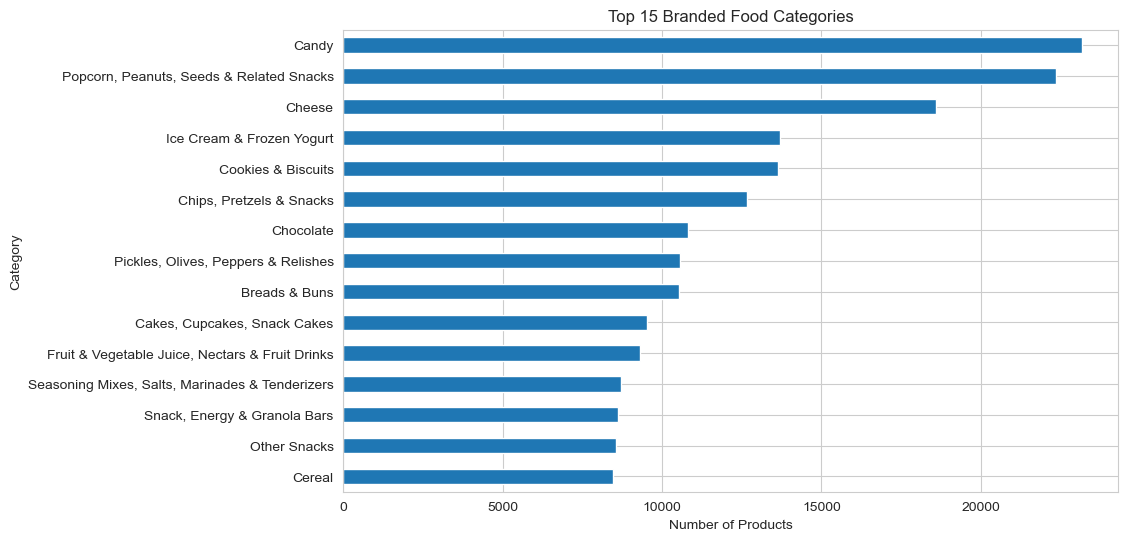

In [42]:
top_categories = (
    barcode_latest["branded_food_category"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 15 Branded Food Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

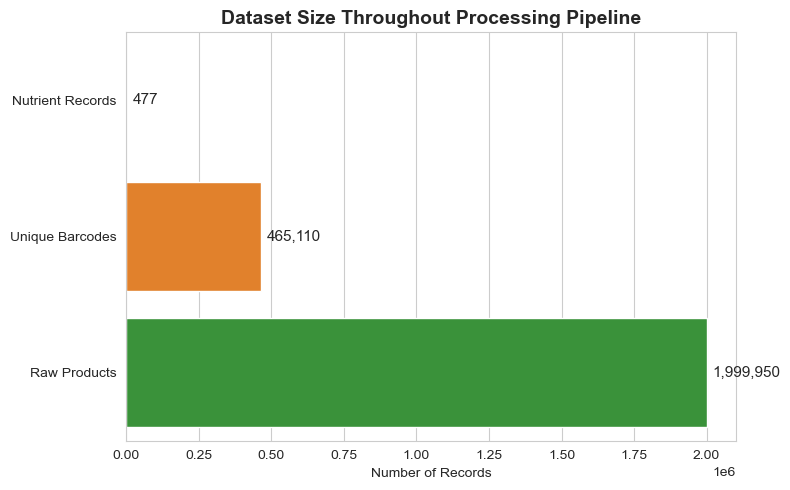

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

dataset_summary = pd.DataFrame({
    "Dataset": [
        "Raw Products",
        "Unique Barcodes",
        "Nutrient Records"
    ],
    "Count": [
        1999950,
        465110,
        nutrient["id"].nunique()
    ]
})

# Sort for better visualization
dataset_summary = dataset_summary.sort_values("Count")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=dataset_summary,
    x="Count",
    y="Dataset"
)

# Add value labels
for i, v in enumerate(dataset_summary["Count"]):
    ax.text(
        v + dataset_summary["Count"].max()*0.01,
        i,
        f"{v:,.0f}",
        va='center',
        fontsize=11
    )

plt.title(
    "Dataset Size Throughout Processing Pipeline",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Records")
plt.ylabel("")
plt.tight_layout()
plt.show()

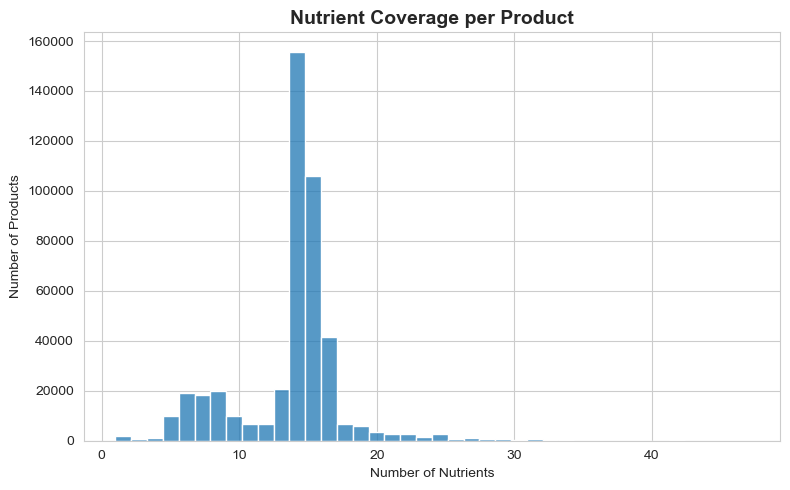

In [48]:
nutrient_count = (
    usda_branded_nutrients_long_clean.groupby("barcode")["nutrient_name"]
      .nunique()
)

plt.figure(figsize=(8,5))
sns.histplot(nutrient_count, bins=40)

plt.title(
    "Nutrient Coverage per Product",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Nutrients")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

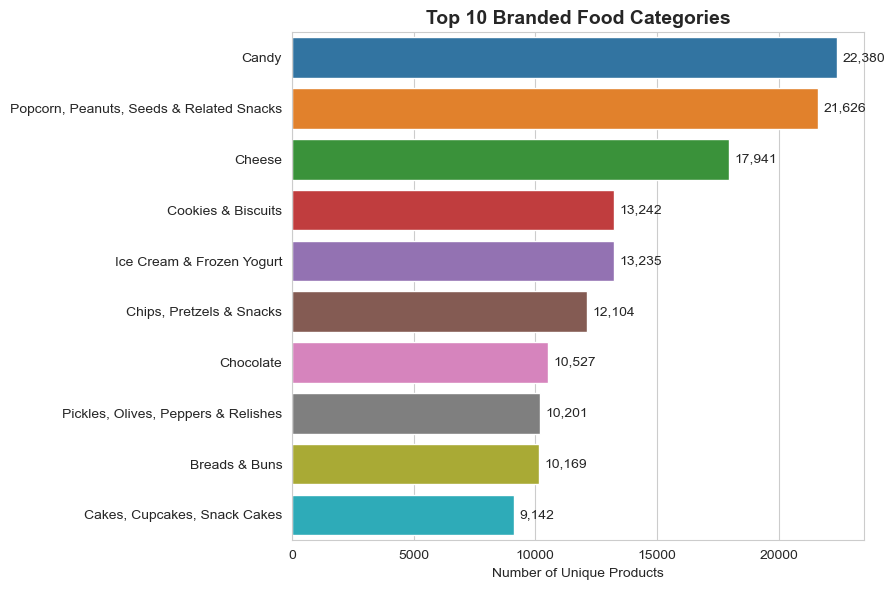

In [49]:
top_categories = (
    usda_branded_nutrients_long_clean[["barcode", "branded_food_category"]]
    .drop_duplicates()
    .dropna()
    ["branded_food_category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

for i, v in enumerate(top_categories.values):
    ax.text(v + top_categories.max()*0.01, i, f"{v:,.0f}", va="center")

plt.title("Top 10 Branded Food Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Unique Products")
plt.ylabel("")
plt.tight_layout()
plt.show()

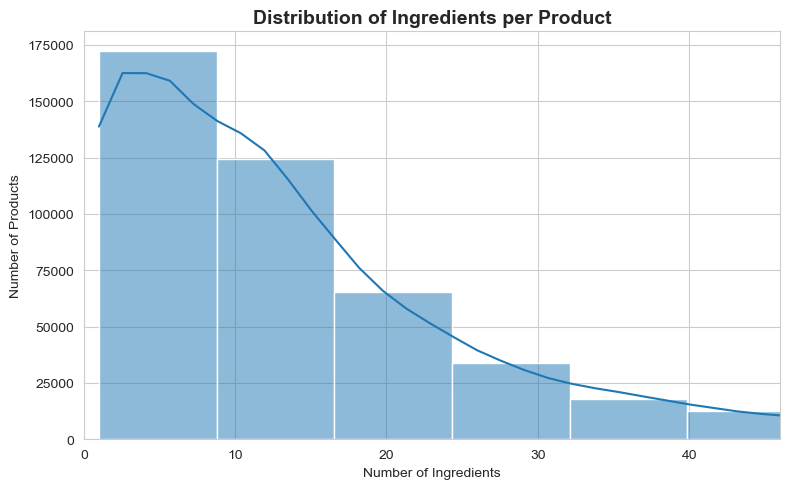

In [50]:
product_ingredients = (
    usda_branded_nutrients_long_clean[["barcode", "ingredients"]]
    .drop_duplicates()
    .dropna()
)

product_ingredients["ingredient_count"] = (
    product_ingredients["ingredients"]
    .str.split(",")
    .str.len()
)

plt.figure(figsize=(8,5))

sns.histplot(
    product_ingredients["ingredient_count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Ingredients per Product", fontsize=14, fontweight="bold")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Products")
plt.xlim(0, product_ingredients["ingredient_count"].quantile(0.95))
plt.tight_layout()
plt.show()